In [1]:
%run utilities_general.ipynb
%run utilities_DIRKs_and_PIRKs.ipynb 
load_standard_packages()
change_wordir()
from tqdm import tqdm

import itertools as it
import seaborn as sns
import numbers
analysis = "sensitivity"

C:\Users\andre\AppData\Local\Temp\ipykernel_22136\1467589274.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [2]:
colors, colours = colourblind_palette("own")

#model = "cyclic_2021"
#model = "cyclic_2021_ODE"
#model = "new_PSI"
#model = "new_PSII"
#model = "new_b6f"
model = "with_dpsi"
#model = "latest_dev"

m = load_model(model)


succesfully loaded with_dpsi :D


In [3]:
def signed_doublelog2(x):
    return np.sign(x) * np.log2(np.log2(np.abs(x) + 1) + 1)

def signed_log2(x):
    return np.sign(x) * np.log2(np.abs(x) + 1)

def make_heatmap(dataframe):

    log_result = dataframe.applymap(signed_doublelog2)

    # 1. create fig and ax
    fig, ax = plt.subplots(
        figsize=(log_result.shape[1]*0.8, log_result.shape[0]*0.4)
    )

    # 2. plot into that ax
    sns.heatmap(
        log_result,
        annot=dataframe,
        cmap="coolwarm",
        fmt=".2f",
        center=0,
        cbar=False,
        ax=ax
    )

    #ax.set_title(f"Sensitivity analysis at AL = {pfd_illum}")
    fig.tight_layout()

    return fig, ax

def make_clustermap(dataframe):
    log_result = dataframe.applymap(signed_doublelog2)

    # clustermap creates its own figure, so don't create fig/ax beforehand
    cluster_grid = sns.clustermap(
        log_result,
        annot=dataframe,
        cmap="coolwarm",
        fmt=".2f",
        center=0,        
        row_cluster=True, 
        col_cluster=True,
        cbar=False,
        figsize=(log_result.shape[1]*0.8, log_result.shape[0]*0.4)
    )

    plt.show()
    
    return

In [4]:
results100 = checkpoint("results100", f"{model}/{analysis}", f"DIRK_all_parameters_{100}pfd", overwrite=False)[0]
results750 = checkpoint("results750", f"{model}/{analysis}", f"DIRK_all_parameters_{750}pfd", overwrite=False)[0]
results1500 = checkpoint("results1500", f"{model}/{analysis}", f"DIRK_all_parameters_{1500}pfd", overwrite=False)[0]

Loaded: pickles/with_dpsi/sensitivity\DIRK_all_parameters_100pfd.joblib
Loaded: pickles/with_dpsi/sensitivity\DIRK_all_parameters_750pfd.joblib
Loaded: pickles/with_dpsi/sensitivity\DIRK_all_parameters_1500pfd.joblib


In [5]:
results100

,ECS_tot,ECS_b,gH,vH,ECS_Rsquared,P700plus_tot,P700_b,k_PSI,vPSI,P700_Rsquared
convf,0.059614,0.034305,0.911821,0.971429,-0.013191,0.028283,0.000000,0.041292,0.069573,0.000000
convflumen,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
PSIItot,-0.249374,-0.466274,0.035464,-0.213920,-0.024343,-0.830661,-1.788969,2.167390,1.336821,-0.212851
PSItot,1.060135,0.312064,0.095539,1.155727,0.028255,1.743253,1.756282,-2.590036,-0.846873,0.332193
PQtot,0.238365,0.375659,0.389790,0.628162,0.000000,0.020735,0.000000,0.090560,0.111297,-0.006817
...,...,...,...,...,...,...,...,...,...,...
thioredoxin_tot,-0.119199,-0.196694,-0.199923,-0.319125,0.000000,-0.019670,0.000000,-0.016541,-0.036213,0.000000
e_cbb_tot,-0.005865,-0.022371,-0.036470,-0.042335,0.000000,-0.017068,0.000000,-0.050998,-0.068063,0.000000
k_fd_tr_reductase,-0.106303,-0.183646,-0.180140,-0.286446,0.000000,-0.032344,-0.278812,-0.074081,-0.106425,0.000000
k_e_cbb_activation,0.008090,-0.014389,-0.045451,-0.037360,0.000000,-0.036553,0.000000,-0.095694,-0.132247,-0.006026


## large list

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


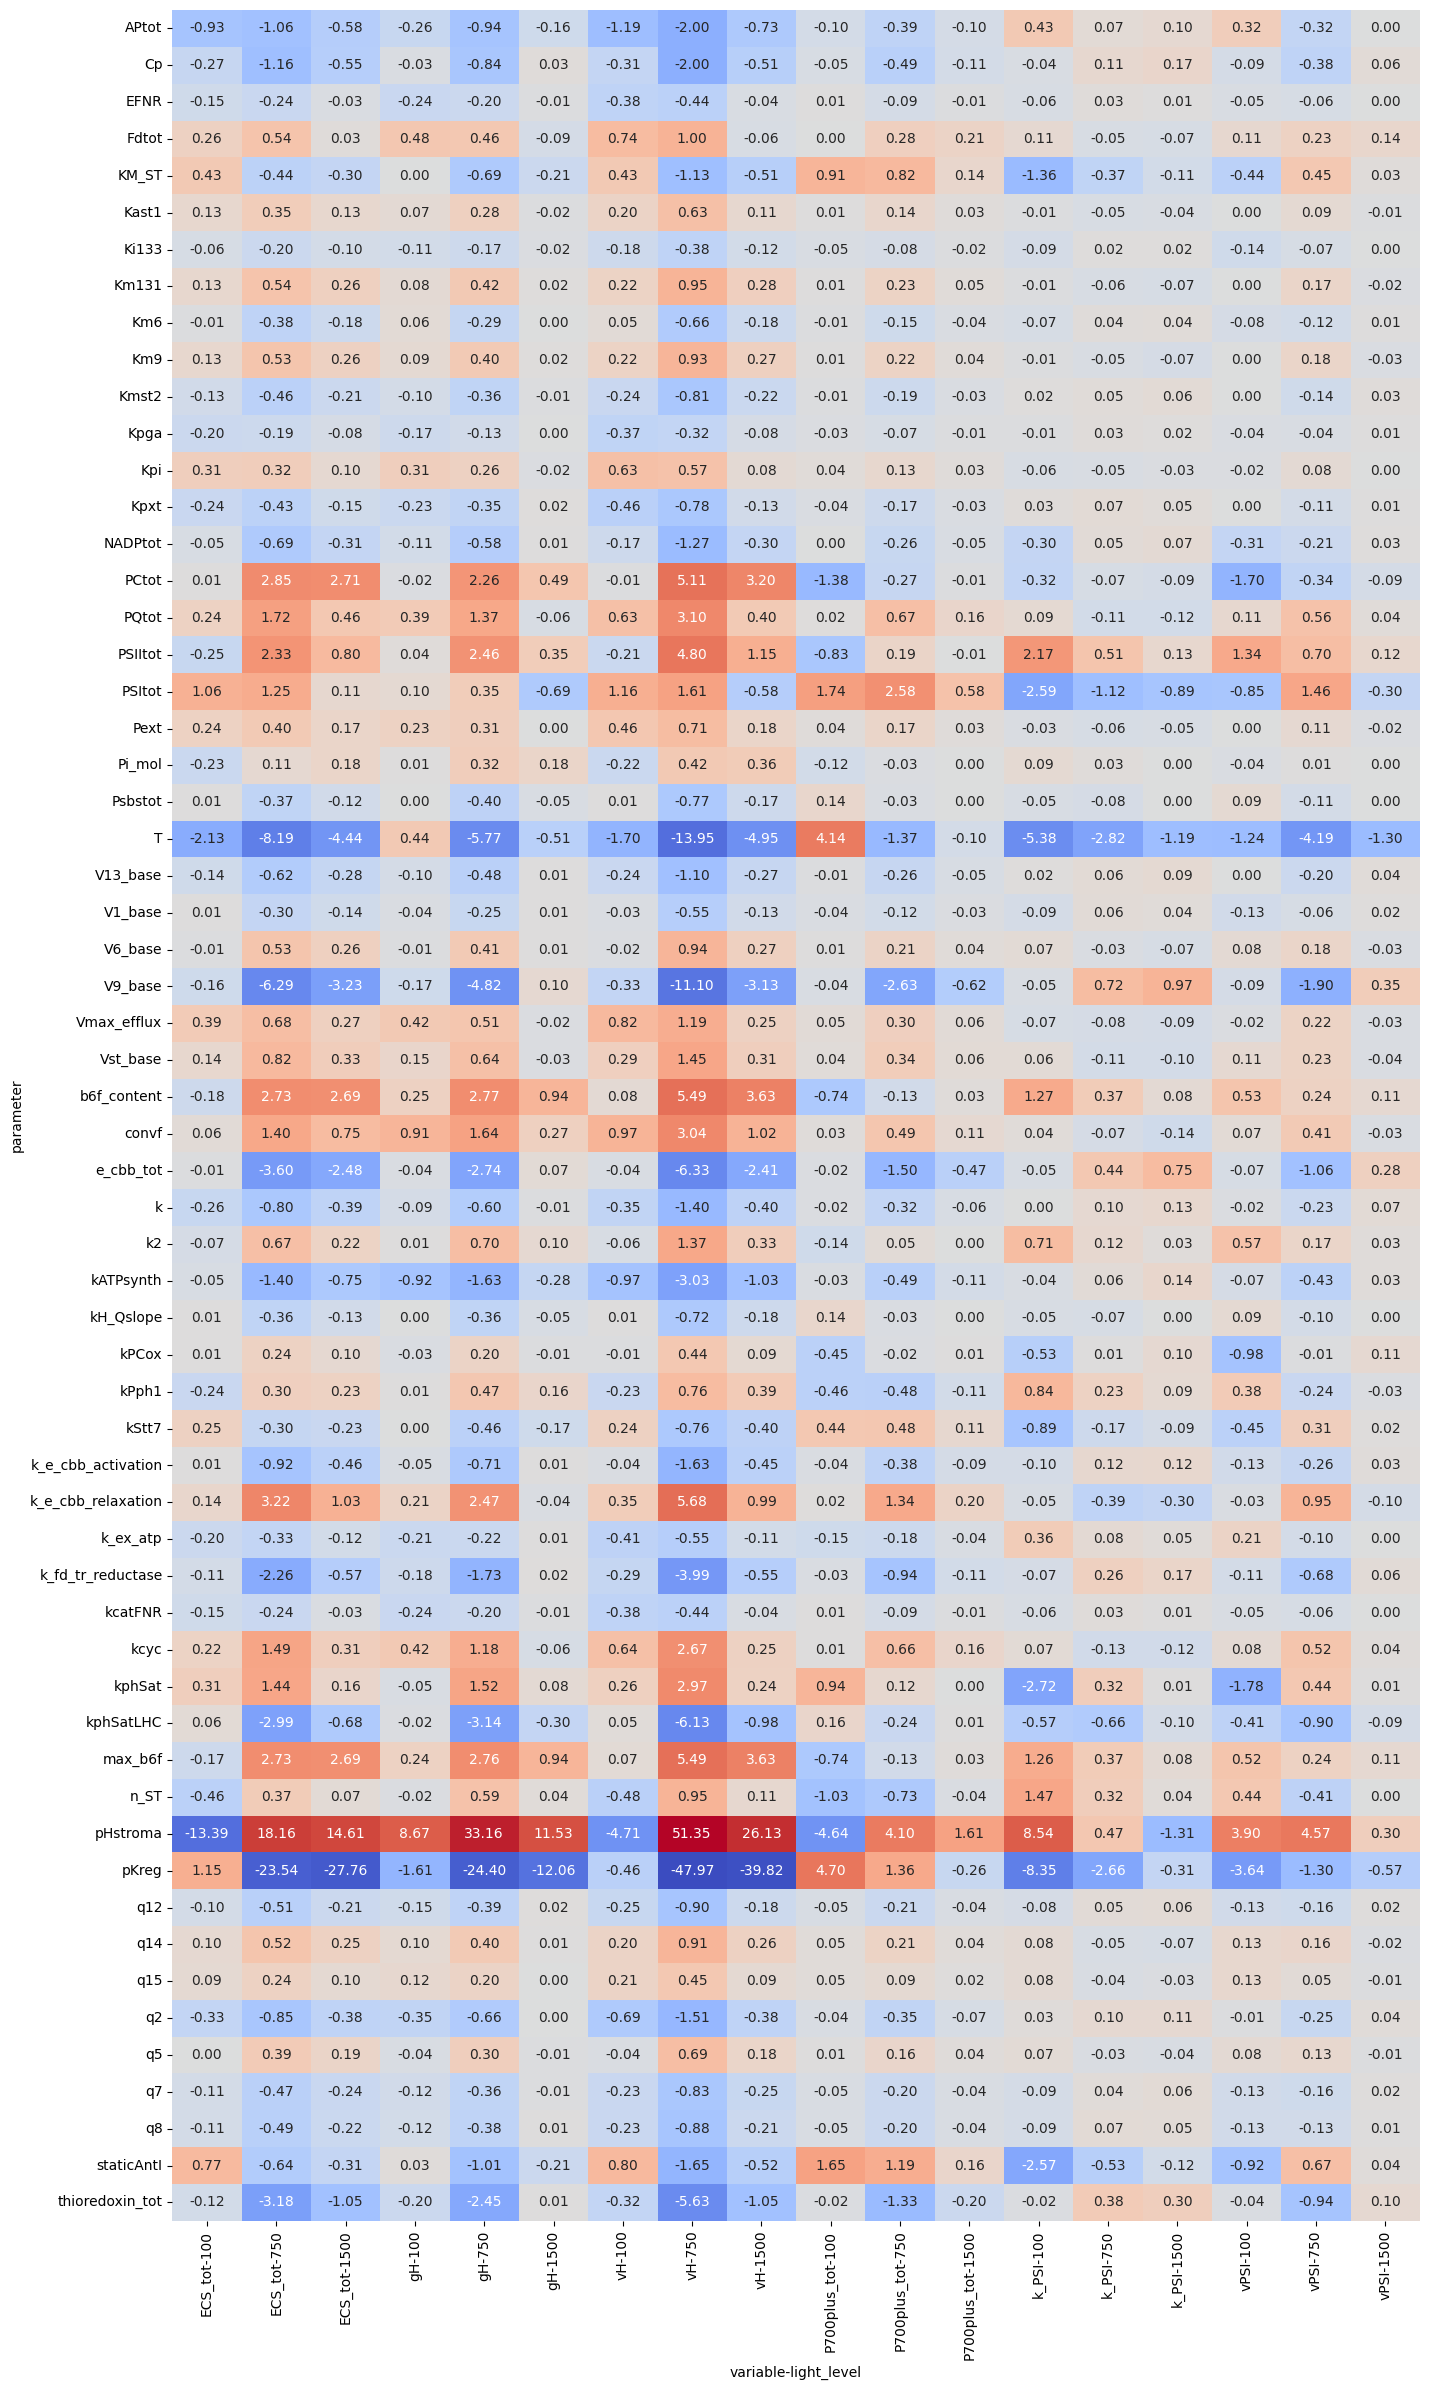

In [10]:
def filter_df(df):
    df = df[df.loc[:,:].abs().mean(axis=1) >= 0.1]
    #print(f"relevant_parameters = {res.index}")
    df = df.drop([#"convf",
                  #"PSIItot", "PSItot", "PQtot", "PCtot", "thioredoxin_tot",
                  #"Fdtot", "NADPtot", "APtot", "Psbstot", "e_cbb_tot", 
                  "DeltaG0_ATP", "F", "R", 
                  "E0_QA", "E0_Fd", "E0_PC", "E0_PQ", "E0_P700", "E0_FA", "HPR"], errors = "ignore")
    return df

def melt_my_dfs(df):
    df_long = df.reset_index().melt(
        id_vars=['index'],           # keep the parameter names
        var_name='variable',         # column names become 'variable'
        value_name='value'           # values go into 'value'
        ).rename(columns={'index': 'parameter'})
    return df_long

results100_long = melt_my_dfs(results100)
results750_long =  melt_my_dfs(results750)
results1500_long = melt_my_dfs(results1500)

results100_long["light_level"] = 100
results750_long["light_level"] = 750
results1500_long["light_level"] = 1500

#print(results1500_filtered.iloc[0:5,0:5])

df_long = pd.concat([results100_long, results750_long, results1500_long], axis=0)

variables_to_plot = ["ECS_tot", "gH", "vH", "P700plus_tot", "k_PSI", "vPSI"] #(in order!)
# parameters_to_plot = ["KM_ST", "PCtot", "PQtot", "PSIItot", "PSItot", "T", "V9_base", "b6f_content", "convf", "e_cbb_tot","kATPsynth", "k_e_cbb_relaxation", "k_fd_tr_reductase", "kcyc", "kphSat", "kphSatLHC", "max_b6f", "n_ST", "pHstroma", "pKreg", "staticAntI", "thioredoxin_tot"]

# FILTER for plotting:
df = df_long[df_long["variable"].isin(variables_to_plot)]

# SORTING
df.variable = pd.Categorical(df['variable'], categories=variables_to_plot, ordered=True) #set sorting order by creating categories
df = df.sort_values(['variable', 'light_level']) # sort dataframe
# df["readouts"] = df["variable"].astype(str) + "__l=" + df["light_level"].astype(str) # combine two columns into one 

# df.readouts = pd.Categorical(df.readouts, categories= df.readouts.unique(),
#                              ordered = True) #set sorting order again, I want to keep as is

wide_format = df.pivot(
    index='parameter',
    columns=['variable', "light_level"],
    values='value'
)

filtered_wide = filter_df(wide_format)

fig, ax = make_heatmap(filtered_wide)
# make_clustermap(
#     filtered_wide)

## smaller lists

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


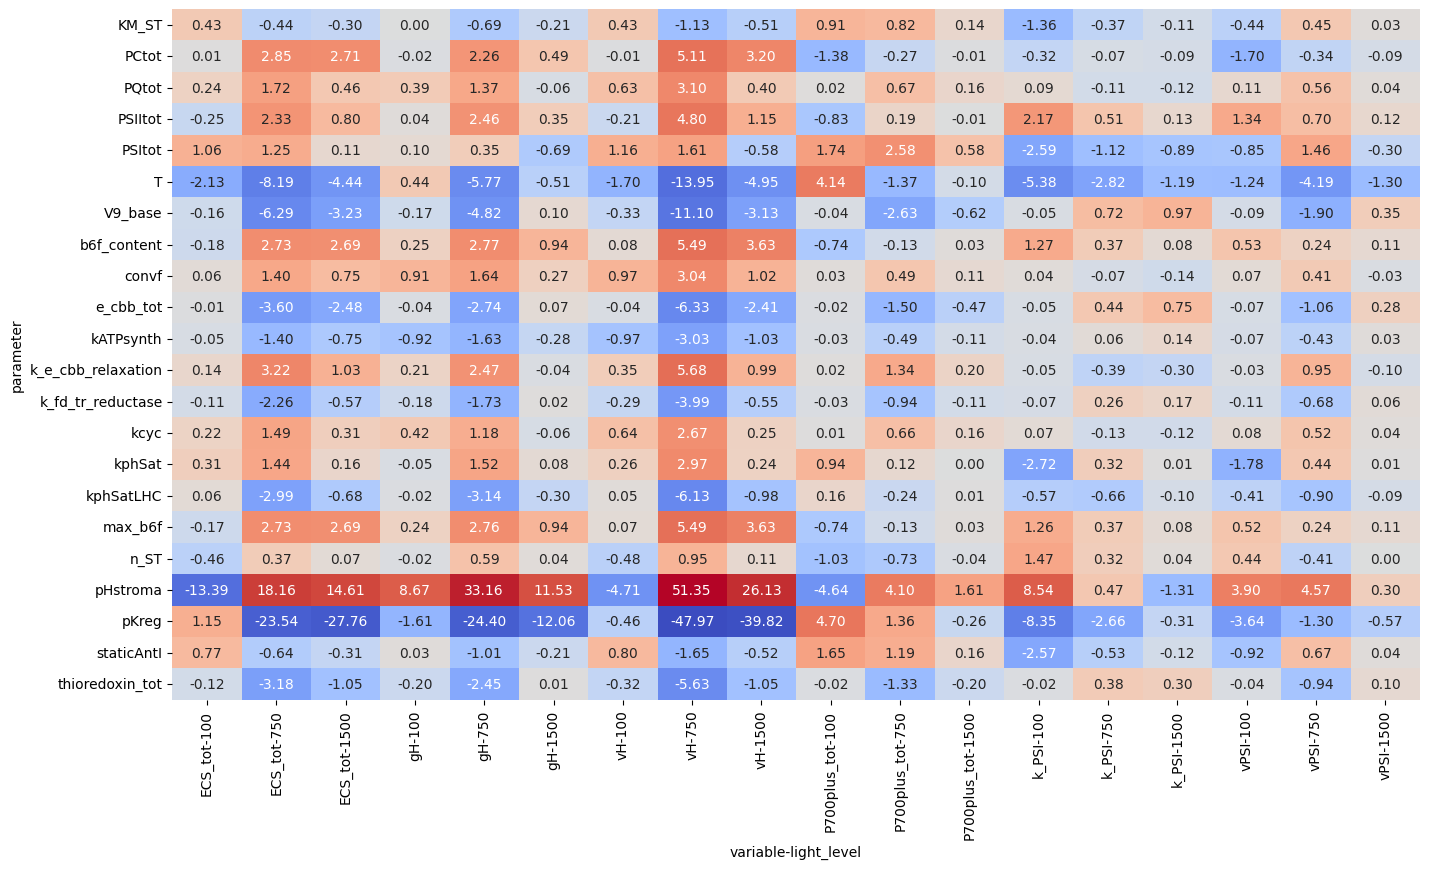

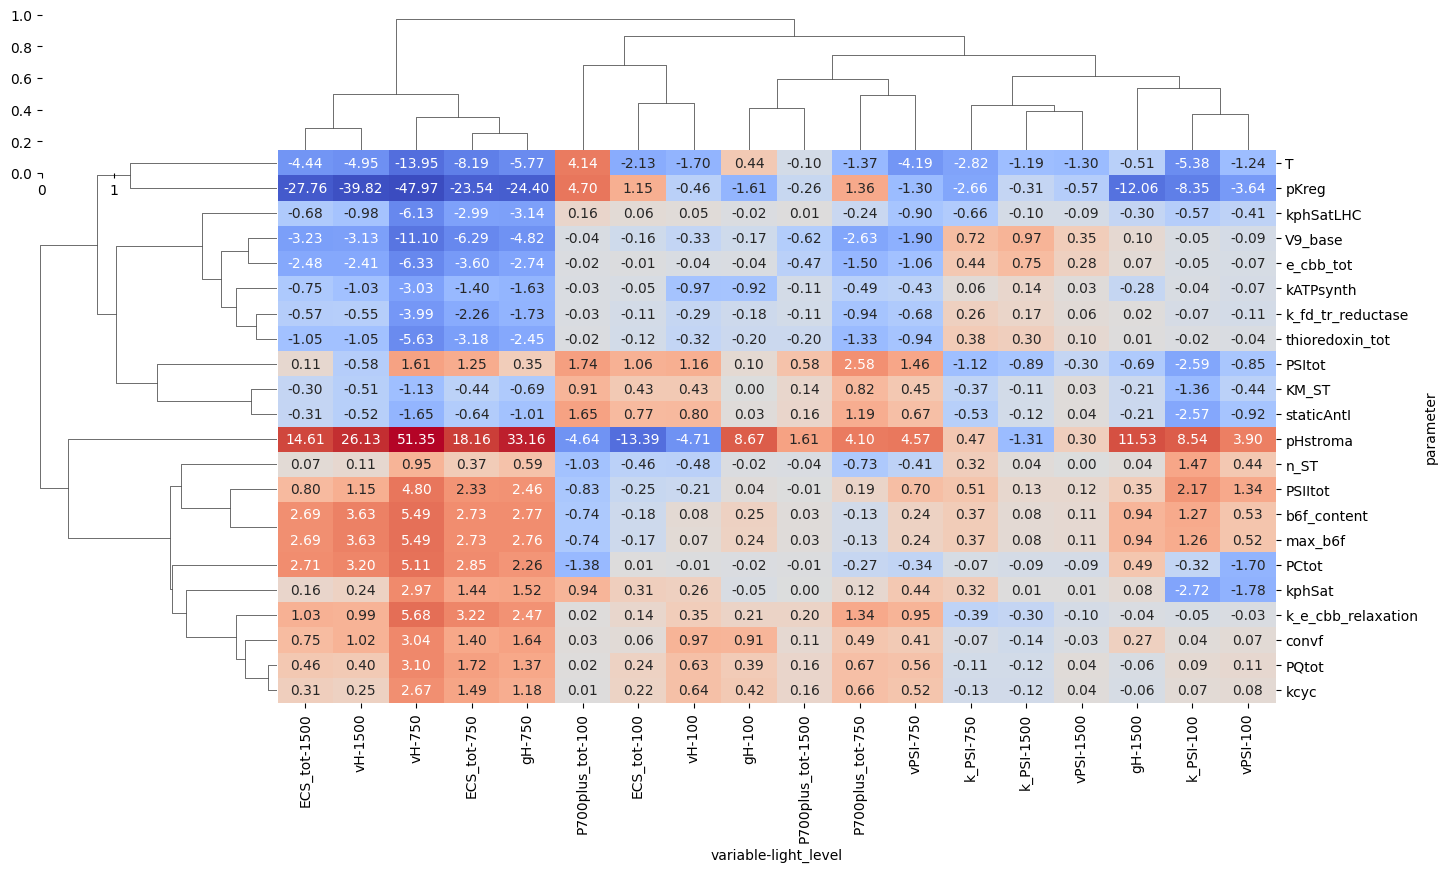

In [23]:
def filter_df(df):
    #df = dataframe[dataframe.loc[:,["k_PSI", "gH"]].abs().max(axis=1) >= 1]
    #print(f"relevant_parameters = {res.index}")
    df = df.drop([#"convf",
                  #"PSIItot", "PSItot", "PQtot", "PCtot", "thioredoxin_tot",
                  #"Fdtot", "NADPtot", "APtot", "Psbstot", "e_cbb_tot", 
                  "DeltaG0_ATP", "F", "R", 
                  "E0_QA", "E0_Fd", "E0_PC", "E0_PQ", "E0_P700", "E0_FA", "HPR"], errors = "ignore")
    return df

def melt_my_dfs(df):
    df_long = df.reset_index().melt(
        id_vars=['index'],           # keep the parameter names
        var_name='variable',         # column names become 'variable'
        value_name='value'           # values go into 'value'
        ).rename(columns={'index': 'parameter'})
    return df_long

results100_long = melt_my_dfs(results100)
results750_long =  melt_my_dfs(results750)
results1500_long = melt_my_dfs(results1500)

results100_long["light_level"] = 100
results750_long["light_level"] = 750
results1500_long["light_level"] = 1500

#print(results1500_filtered.iloc[0:5,0:5])

df_long = pd.concat([results100_long, results750_long, results1500_long], axis=0)

variables_to_plot = ["ECS_tot", "gH", "vH", "P700plus_tot", "k_PSI", "vPSI"] #(in order!)
parameters_to_plot = ["KM_ST", "PCtot", "PQtot", "PSIItot", "PSItot", "T", "V9_base", "b6f_content", "convf", "e_cbb_tot","kATPsynth", "k_e_cbb_relaxation", "k_fd_tr_reductase", "kcyc", "kphSat", "kphSatLHC", "max_b6f", "n_ST", "pHstroma", "pKreg", "staticAntI", "thioredoxin_tot"]

# FILTER for plotting:
df = df_long[df_long["variable"].isin(variables_to_plot)]

# SORTING
df.variable = pd.Categorical(df['variable'], categories=variables_to_plot, ordered=True) #set sorting order by creating categories
df = df.sort_values(['variable', 'light_level']) # sort dataframe
# df["readouts"] = df["variable"].astype(str) + "__l=" + df["light_level"].astype(str) # combine two columns into one 

# df.readouts = pd.Categorical(df.readouts, categories= df.readouts.unique(),
#                              ordered = True) #set sorting order again, I want to keep as is

wide_format = df.pivot(
    index='parameter',
    columns=['variable', "light_level"],
    values='value'
)

filtered_wide = filter_df(wide_format)
filtered_wide = filtered_wide.loc[parameters_to_plot,:]

fig, ax = make_heatmap(filtered_wide)
make_clustermap(
    filtered_wide)

In [46]:
save_fig(fig, model, analysis, f"var_light_heatmap")

existing figure backed up to figures/with_dpsi/sensitivity/Z_backup_var_light_heatmap.png
saved figure to figures/with_dpsi/sensitivity/var_light_heatmap.png


## scatter plots

In [21]:
color_dict = {
    # 'ECS_tot': colors[6],
    # 'ECS_b': colors[7],
    'gH': colors[4],
    'vH': colors[0],
    # 'P700plus_tot': colors[4],
    # 'P700_b': colors[3],
    'k_PSI': colors[1],
    'vPSI': colors[5]
}

light_marker_map = {100: 'o', 750: 's', 1500: 'P'}

In [25]:
df_long

,parameter,variable,value,light_level
0,convf,ECS_tot,0.059614,100
1,convflumen,ECS_tot,0.000000,100
2,PSIItot,ECS_tot,-0.249374,100
3,PSItot,ECS_tot,1.060135,100
4,PQtot,ECS_tot,0.238365,100
...,...,...,...,...
1875,thioredoxin_tot,P700_Rsquared,0.000000,1500
1876,e_cbb_tot,P700_Rsquared,0.011613,1500
1877,k_fd_tr_reductase,P700_Rsquared,0.000000,1500
1878,k_e_cbb_activation,P700_Rsquared,0.000000,1500


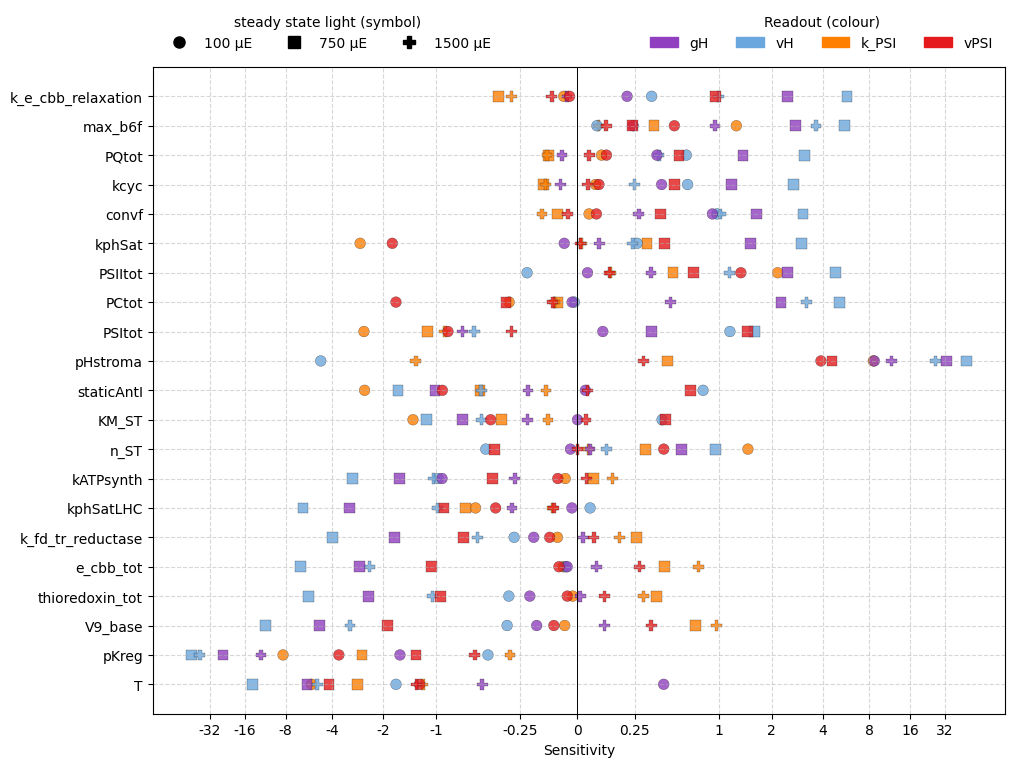

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

# -- reuse your setup --

parameters_to_plot = ["pKreg", "pHstroma", "kphSatLHC", "T", "V9_base", "k_e_cbb_relaxation",
                      "staticAntI", "kATPsynth", "kcyc", "kphSat", "k_fd_tr_reductase", "KM_ST", "n_ST", "max_b6f",
                      "PCtot", "PQtot", "PSIItot", "PSItot", "convf", "e_cbb_tot", "thioredoxin_tot"] # all with at least one sensitivity above 1

df_long_filt = df_long[df_long['parameter'].isin(parameters_to_plot)].copy()

# Transform values
df_long_filt['transformed_value'] = df_long_filt['value'].apply(signed_doublelog2)

# Compute mean transformed value per parameter and sort descending
param_order = (
    df_long_filt.groupby('parameter')['transformed_value']
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)

# Reassign categorical with the new order and sort accordingly
df_long_filt['parameter'] = pd.Categorical(df_long_filt['parameter'], categories=param_order, ordered=True)
df_long_filt = df_long_filt.sort_values('parameter')

# Set other plot-relevant columns
df_long_filt['size'] = 60
df_long_filt['marker'] = df_long_filt['light_level'].map(light_marker_map)

# -- start plotting --
fig, ax = plt.subplots(figsize=(11, len(df_long_filt['parameter'].unique()) / 2.5))

# Plot manually
for var in df_long_filt['variable'].unique():
    if var not in color_dict:
        continue
    var_df = df_long_filt[df_long_filt['variable'] == var]
    color = color_dict[var]
    for light, marker in light_marker_map.items():
        sub_df = var_df[var_df['light_level'] == light]
        ax.scatter(
            sub_df['transformed_value'],
            sub_df['parameter'],
            s=sub_df['size'],
            c=color,
            marker=marker,
            edgecolor='black',
            linewidth=0.2,
            alpha=0.8
        )

# -- custom x-axis: show original value ticks but plot transformed values --
orig_xticks = np.array([-32, -16, -8, -4, -2, -1, -0.25, 0, 0.25, 1, 2, 4, 8, 16, 32])
transformed_xticks = [signed_doublelog2(x) for x in orig_xticks]
ax.set_xticks(transformed_xticks)
ax.set_xticklabels([f"{x:.2g}" for x in orig_xticks])

ax.set_xlabel("Sensitivity")
ax.grid(True, linestyle='--', alpha=0.5)

# -- vertical line at x=0 --
ax.axvline(x=signed_doublelog2(0), color='black', linestyle='-', linewidth=0.7)

# -- construct legends manually --
var_patches = [mpatches.Patch(color=color_dict[var], label=var) for var in color_dict]
light_lines = [
    mlines.Line2D([], [], color='black', marker=marker, linestyle='None',
                  markersize=8, label=f'{light} µE')
    for light, marker in light_marker_map.items()
]

leg1 = ax.legend(handles=var_patches, title='Readout (colour)', loc='upper right',
                 bbox_to_anchor=(1, 1.1), ncol=4, frameon=False)
leg2 = ax.legend(handles=light_lines, title='steady state light (symbol)', loc='upper left',
                 bbox_to_anchor=(0, 1.1), ncol=3, frameon=False)
ax.add_artist(leg1)

plt.show()


In [27]:
save_fig(fig, model, analysis, f"var_light_scatterplot")

existing figure backed up to figures/with_dpsi/sensitivity/Z_backup_var_light_scatterplot.png
saved figure to figures/with_dpsi/sensitivity/var_light_scatterplot.png
